In [1]:
# IPython extension to reload modules before executing user code.
# useful to see immediate results in notebook when modifying imported scripts
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import sys
import os


# Add the ../py directory to sys.path
# This allows importing modules from the py directory as if they were in the current directory
module_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'py'))
if module_path not in sys.path:
    sys.path.append(module_path)

# Verify it works
print(f"Added to path: {module_path}")

Added to path: /Users/eyal/projects/elzurdo/dpitg/py


In [32]:
from utils import print_env_info, report_accounting_size

from utils_viz import (
    FIG_WIDTH,
    FIG_HEIGHT,
    SMALL_SIZE,
    MEDIUM_SIZE,
    BIGGER_SIZE,
    # plot_sample_pdf_methods,
    # viz_sequence_stats
)

from utils_experiments_binomial import (
    BinaryAccounting,
    BinomialSimulation,
    BinomialHypothesis, 
    # stop_decision_multiple_sequences_multiple_methods,
    # sequence_to_iteration_stats,
    # SEQUENCE_HANDPICKED,
    # stats_dict_to_df,
    )


from utils_experiments_shared import (
    SEED,
    report_success_rates_multiple_algos
)

In [11]:
print_env_info()

Last run: 2026-06-27 10:49:15.369046
Python: 3.10.13
Platform: macOS-13.0-x86_64-i386-64bit
pandas: 2.3.3
numpy: 2.2.6
scipy: 1.15.3
matplotlib: 3.10.9
notebook: 7.6.0


In [8]:
plt.rc("font", size=SMALL_SIZE)  # controls default text sizes
plt.rc("axes", titlesize=SMALL_SIZE)  # fontsize of the axes title
plt.rc("axes", labelsize=MEDIUM_SIZE)  # fontsize of the x and y labels
plt.rc("xtick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("ytick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("legend", fontsize=SMALL_SIZE)  # legend fontsize
plt.rc("axes", titlesize=BIGGER_SIZE)  # fontsize of the figure title

plt.rcParams["figure.figsize"] = FIG_WIDTH, FIG_HEIGHT
# plt.rcParams["hatch.linewidth"] = 0.2

plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False

# Aux

In [12]:
# used for storing an linking to binary calucations already performed
binary_accounting = BinaryAccounting()

print(binary_accounting.dict_successes_failures_counter, binary_accounting.dict_successes_failures_hdi_limits)
print("-" * 20)
report_accounting_size(binary_accounting)

{} {}
--------------------
Binary Accounting Report
0 elements in 0.00 MBytes)
The binary counter is empty


# Experiments

## Fair Coin Sequences

In [41]:
θ_true = 0.5

N_EXPERIMENTS = 100 # 2000
N_SAMPLES = 1500  # in paper called M

In [42]:
%%time

# was called synth_0pt5
sequences_0pt5 = BinomialSimulation(
    success_rate=θ_true,
    n_samples = N_SAMPLES,
    n_experiments = N_EXPERIMENTS,
    seed=SEED)

Generating synthetic data with parameter values:
0.5: true success rate
100: experiments
1500: sample size per experiment
CPU times: user 4.95 ms, sys: 1.07 ms, total: 6.03 ms
Wall time: 4.95 ms


## Hypothesis

In [43]:
θ_null = 0.5
dsuccess_rate = 0.05
rope_precision_fraction = 0.8

In [44]:
hypothesis_0pt5 = BinomialHypothesis(
    success_rate_null=θ_null, 
    dsuccess_rate=dsuccess_rate, 
    rope_precision_fraction=rope_precision_fraction)

0.5: null hypothesis
0.45: ROPE min
0.55: ROPE max
--------------------
0.08: Precision Goal


In [45]:
%%time
# Timing sensitive to how complete binary_accounting is.
# From empty when setting:
# tbd
# tbd
# I takes ~ X minutes on macOS-13.0-x86_64-i386-64bit.

hypothesis_0pt5.run_hypothesis_on_experiments(sequences_0pt5.experiments, binary_accounting)


,accept,reject,conclusive,inconclusive,stop_iter_mean,stop_iter_std,success_rate_mean,success_rate_std
hdi_rope,0.88,0.09,0.97,0.03,613.12,334.674794,0.494509,0.056340
pitg,0.36,0.00,0.36,0.64,598.10,1.611198,0.501727,0.021544
dpitg,0.96,0.00,0.96,0.04,769.02,253.391300,0.501342,0.013849


CPU times: user 1min 50s, sys: 440 ms, total: 1min 51s
Wall time: 1min 51s


In [46]:
report_accounting_size(binary_accounting)

Binary Accounting Report
33,366 elements in 5.07 MBytes)
Most frequent count value: 577 (appears 48 times (of 33,366 0.14%))
Max sum 1,500
e.g, key (np.int64(799), np.int64(701)) appears 1 time(s) yiedling (np.float64(0.5074142760260834), np.float64(0.5578881163957048)) HDI limits



viz_epitg separate


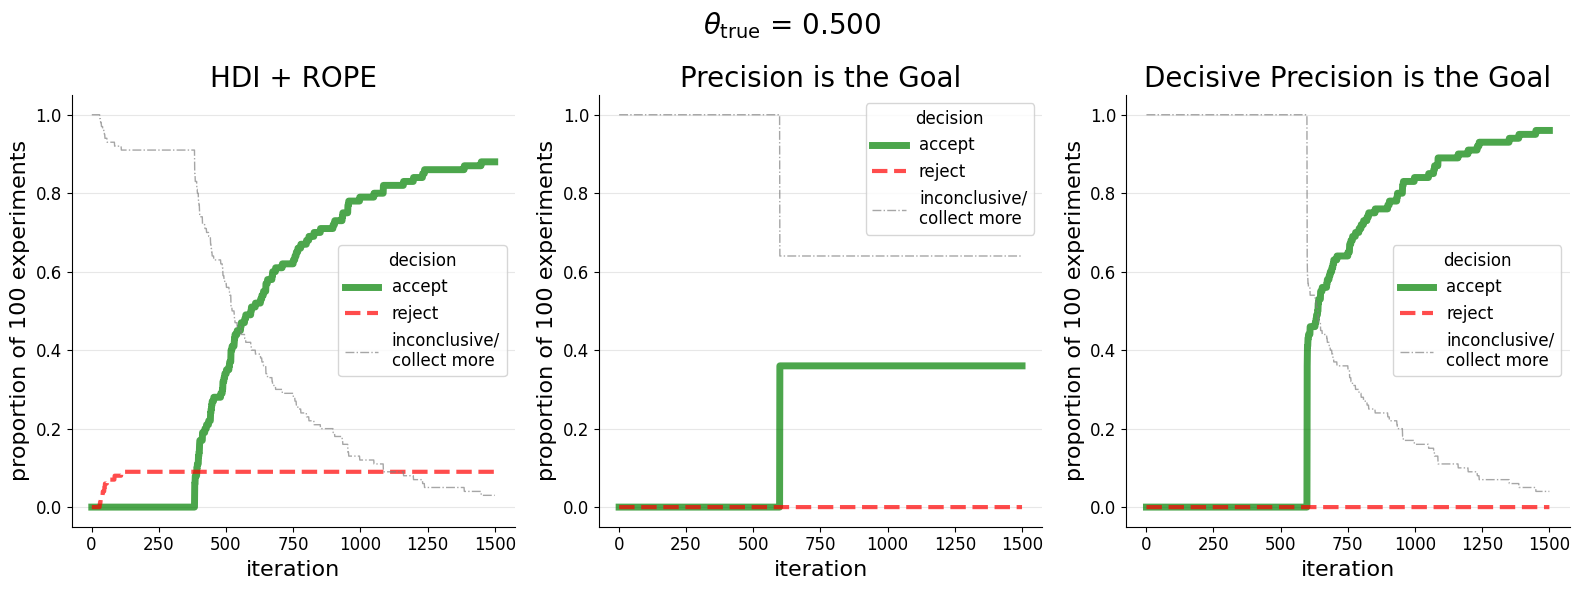

In [47]:
hypothesis_0pt5.plot_decision_rates(sequences_0pt5.success_rate, viz_epitg="separate")

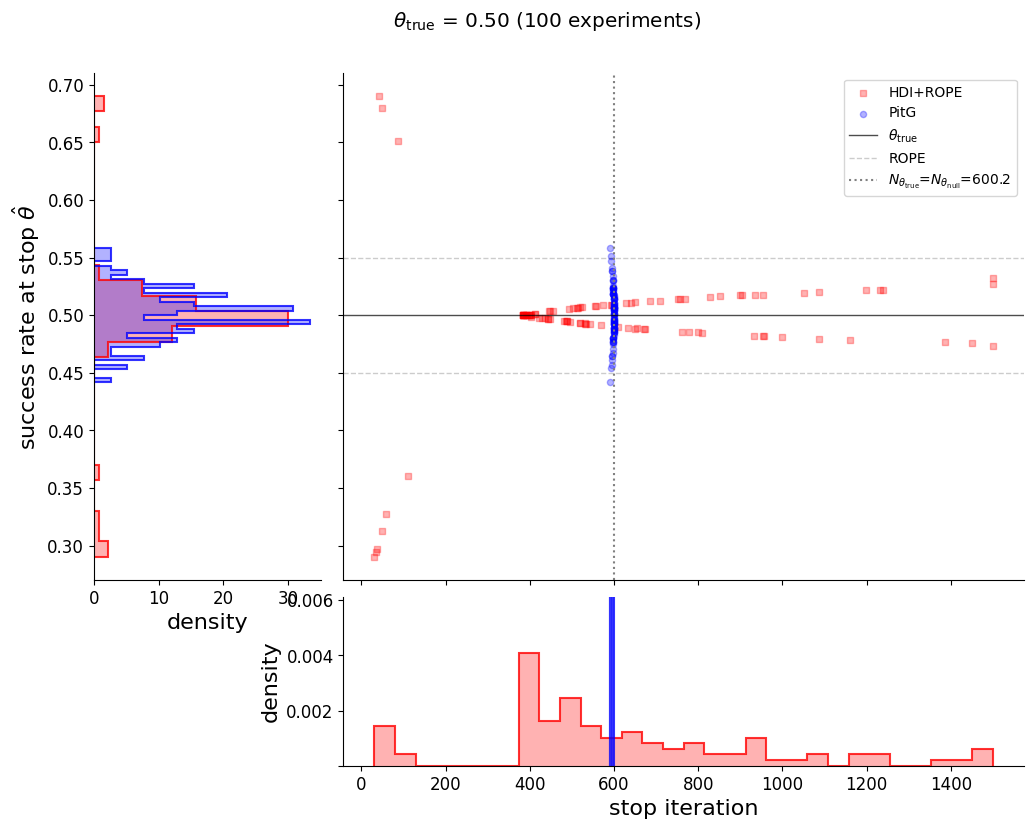

In [48]:
hypothesis_0pt5.plot_stop_iter_sample_rates(success_rate=sequences_0pt5.success_rate, title=None)

In [49]:
# Summary Stats
df_θtrue0pt5_θnull0pt5 = report_success_rates_multiple_algos(hypothesis_0pt5.method_df_stats.copy())

count  param_frac  param_mean  param_std  param_p25  \
algorithm group                                                               
pitg      overall         100        1.00    0.501727   0.021544   0.488731   
          conclusive       36        0.36    0.500510   0.005767   0.495409   
          inconclusive     64        0.64    0.502411   0.026637   0.479933   
          accept           36        0.36    0.500510   0.005767   0.495409   
dpitg     overall         100        1.00    0.501342   0.013849   0.490000   
          conclusive       96        0.96    0.500683   0.012707   0.490000   
          inconclusive      4        0.04    0.517167   0.029476   0.513333   
          accept           96        0.96    0.500683   0.012707   0.490000   
hdi_rope  overall         100        1.00    0.494509   0.056340   0.490962   
          conclusive       97        0.97    0.494002   0.056943   0.491228   
          inconclusive      3        0.03    0.510889   0.032662   0.500000   
          accept           88        0.88    0.500163   0.011454   0.493097   
          reject            9        0.09    0.433758   0.181612   0.297297   

                        param_median  param_p75  stop_iter_mean  \
algorithm group                                                   
pitg      overall           0.501669   0.516277      598.100000   
          conclusive        0.500835   0.505843      599.000000   
          inconclusive      0.510851   0.522157      597.593750   
          accept            0.500835   0.505843      599.000000   
dpitg     overall           0.501669   0.512248      769.020000   
          conclusive        0.500835   0.511196      738.562500   
          inconclusive      0.529667   0.533500     1500.000000   
          accept            0.500835   0.511196      738.562500   
hdi_rope  overall           0.500000   0.509251      613.120000   
          conclusive        0.500000   0.508711      585.690722   
          inconclusive      0.526667   0.529667     1500.000000   
          accept            0.500000   0.508259      639.943182   
          reject            0.327586   0.651163       55.222222   

                        stop_iter_std  stop_iter_p25  stop_iter_median  \
algorithm group                                                          
pitg      overall            1.611198         598.00             599.0   
          conclusive         0.000000         599.00             599.0   
          inconclusive       1.831980         597.00             598.0   
          accept             0.000000         599.00             599.0   
dpitg     overall          253.391300         599.00             639.0   
          conclusive       208.506610         599.00             633.0   
          inconclusive       0.000000        1500.00            1500.0   
          accept           208.506610         599.00             633.0   
hdi_rope  overall          334.674794         402.75             527.0   
          conclusive       300.278807         402.00             519.0   
          inconclusive       0.000000        1500.00            1500.0   
          accept           259.504229         441.25             538.0   
          reject            26.668229          37.00              48.0   

                        stop_iter_p75  conclusive_mean  accept_mean  \
algorithm group                                                       
pitg      overall              599.00             0.36     0.360000   
          conclusive           599.00             1.00     1.000000   
          inconclusive         599.00             0.00     0.000000   
          accept               599.00             1.00     1.000000   
dpitg     overall              834.00             0.96     0.960000   
          conclusive           802.25             1.00     1.000000   
          inconclusive        1500.00             0.00     0.000000   
          accept               802.25             1.00     1.000000   
hdi_rope  o

In [50]:
algo_names = ["hdi_rope", "pitg", "dpitg"]

cols_overall = ["count", "conclusive_mean",  "stop_iter_median", "stop_iter_p25", "stop_iter_p75"]

df_θtrue0pt5_θnull0pt5.reset_index().query("group == 'overall'").set_index("algorithm").loc[algo_names][cols_overall]

,count,conclusive_mean,stop_iter_median,stop_iter_p25,stop_iter_p75
algorithm,,,,,
hdi_rope,100,0.97,527.0,402.75,770.75
pitg,100,0.36,599.0,598.00,599.00
dpitg,100,0.96,639.0,599.00,834.00


In [51]:
cols_conclusive = ["count", "accept_mean", "reject_mean", "param_median", "param_p25", "param_p75", "stop_iter_median", "stop_iter_p25", "stop_iter_p75"]

df_θtrue0pt5_θnull0pt5.reset_index().query("group == 'conclusive'").set_index("algorithm").loc[algo_names][cols_conclusive]

,count,accept_mean,reject_mean,param_median,param_p25,param_p75,stop_iter_median,stop_iter_p25,stop_iter_p75
algorithm,,,,,,,,,
hdi_rope,97,0.907216,0.092784,0.500000,0.491228,0.508711,519.0,402.0,757.00
pitg,36,1.000000,0.000000,0.500835,0.495409,0.505843,599.0,599.0,599.00
dpitg,96,1.000000,0.000000,0.500835,0.490000,0.511196,633.0,599.0,802.25


In [52]:
hypothesis_0pt5.decision_correctness(θ_true)

hypothesis_0pt5.df_experiment_correctness.head(4)

,hdi_rope_decision_iteration,hdi_rope_accept,hdi_rope_reject_below,hdi_rope_reject_above,hdi_rope_inconclusive,hdi_rope_param_value,hdi_rope_decision_correct,pitg_decision_iteration,pitg_accept,pitg_reject_below,...,pitg_inconclusive,pitg_param_value,pitg_decision_correct,dpitg_decision_iteration,dpitg_accept,dpitg_reject_below,dpitg_reject_above,dpitg_inconclusive,dpitg_param_value,dpitg_decision_correct
experiment_idx,,,,,,,,,,,,,,,,,,,,,
0,640,True,False,False,False,0.510938,True,598,False,False,...,True,0.521739,True,640,True,False,False,False,0.510938,True
1,502,True,False,False,False,0.505976,True,599,True,False,...,False,0.505843,True,599,True,False,False,False,0.505843,True
2,398,True,False,False,False,0.5,True,599,True,False,...,False,0.504174,True,599,True,False,False,False,0.504174,True
3,496,True,False,False,False,0.493952,True,599,True,False,...,False,0.492487,True,599,True,False,False,False,0.492487,True


# Examining Individual Sequences

## Sequences with Disagreeing Stops

In [53]:
# experiment ids for which:
# - HDI_ROPE method had success rate > 0.55
# - PITG method was inconclusive
# - DPITG method was conclusive

experiment_idxs = list(sorted(set(hypothesis_0pt5.method_df_stats["pitg"].query("inconclusive").index) &\
set(hypothesis_0pt5.method_df_stats["dpitg"].query("accept").index) &\
set(hypothesis_0pt5.method_df_stats["hdi_rope"].query("success_rate > 0.55").index)))
len(experiment_idxs)

1

1001100110111101110000111101111110110111110011100101110110000111110111111101100100111000001100110100010001000010010001111111001101000101110100100010111100001001111110110011001100101000000101010011111011110011110001101001011100111001100100001000010100001010001000011111010011110001100011011010001101011001011100010011011001100010011100011001101111111001110101000100001001111101111100110110110100010010111100110101111101111011001000110110010100101000000110100100011001100011001110110111100010101111100010101111001011101000000101001100001101011101010010111001011111000111110001011000010110111000011100100101011011101011010011001100111011011011110010010100111111110101011111010101111101100010001111001001010100011011110110011111000001111111001010110100010100100011000011101111110101110001110110111101111111000110011100000000100111111111011100101111111111100001010001001001000010110100001011011000010111000010001110011110010100100010010101011100100101011110110101011010000010101101110011001110000011100001

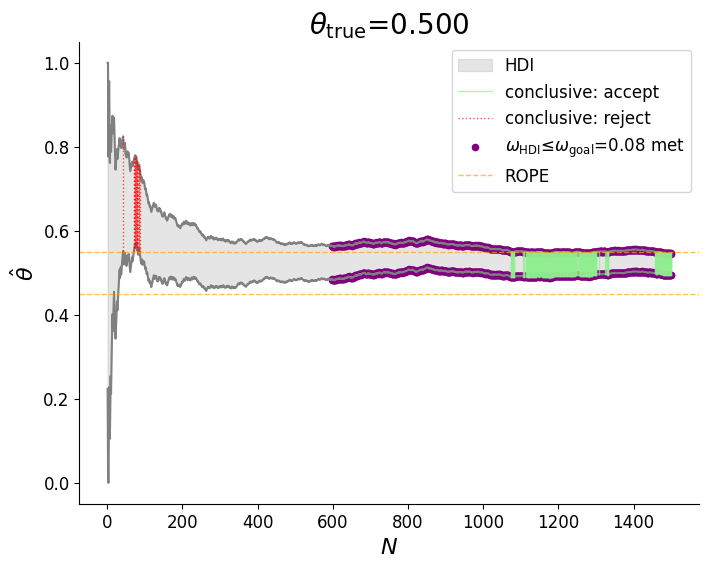

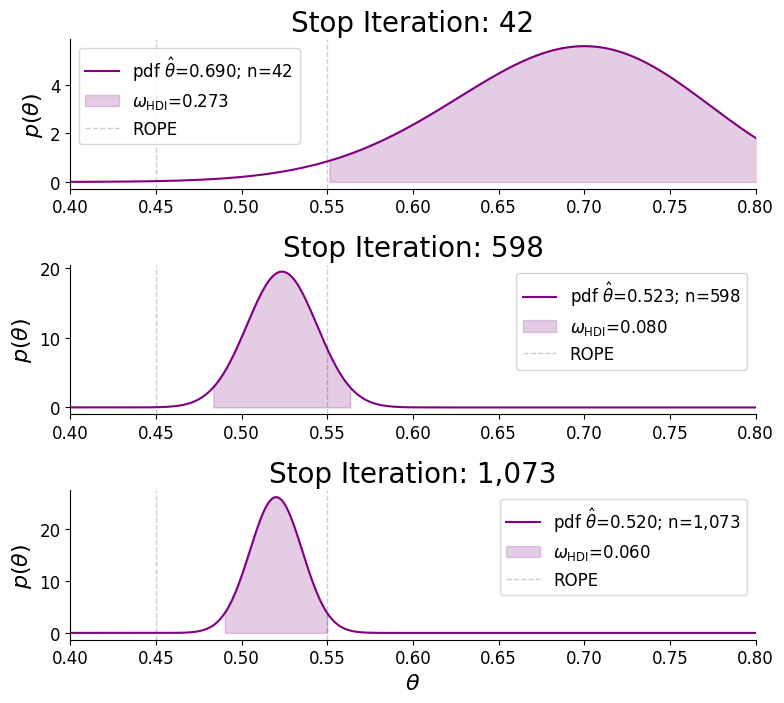

In [60]:
# Visualising outcomes of one experiment

iexperiment = experiment_idxs[0]
#iexperiment = experiment_idxs[1]  # good example
#iexperiment = experiment_idxs[2]  # good example. HAND PICKED FOR PAPER.

# for viz
method_names = ["hdi_rope", "pitg", "dpitg"]

print("".join([f"{b_}" for b_ in hypothesis_0pt5.experiments[iexperiment,:] ]))

xlim = (0.4, 0.8)
df_experiment_results = hypothesis_0pt5.one_experiment_all_iterations(iexperiment, binary_accounting=binary_accounting, viz=True, θ_true=θ_true, method_names=method_names, xlim=xlim)

